In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import shapely # map-rendering library
import numpy as np
import fiona # enging for reading more robust data files
import contextily as cx
import os

In [2]:
os.chdir("/users/sankarana/MinGenResources-DFW")

In [3]:
# 2020 block data
#blocks = gpd.read_file("tl_2020_48_tabblock20.shp", engine="fiona")

In [4]:
#blocks[blocks['COUNTYFP20']=='113']["TRACTCE20"].sort_values().unique()
#blocks[blocks['COUNTYFP20']=='113'].sort_values('TRACTCE20').value_counts()

In [5]:
#dallas_county_blocks = blocks[blocks['COUNTYFP20']=='113']
#dallas_county_blocks.to_file("dallas_county_blocks.geojson")

In [6]:
dallas_county_blocks = gpd.read_file("Census_Data/Blocks/dallas_county_blocks.geojson")
age = pd.read_csv("Census_Data/Blocks/block_population_age.csv")

In [7]:
#dallas_county_blocks['GEOID20']
#age.info()
#dallas_county_blocks.isna().sum()
#age.isna().sum()

In [8]:
#dallas_county_blocks[dallas_county_blocks["GEOID20"] == "481130001001000"]

In [9]:
age["GEO_ID"] = age["GEO_ID"].str[9:]

In [10]:
dallas_county_blocks = dallas_county_blocks.rename(columns={"GEOID20": "GEO_ID"})

In [11]:
dallas_county_blocks = dallas_county_blocks[["GEO_ID", "INTPTLAT20", "INTPTLON20", "HOUSING20", "POP20", "geometry"]]
age = age[["GEO_ID", "P15_001N", "P15_002N", "P15_003N"]]

In [12]:
age = age.rename(columns={"P15_001N": "Total", "P15_002N": "Children", "P15_003N": "Adults"})
age = age.drop(labels = 0, axis = 0)

In [13]:
#dallas_county_blocks.head()
#age.head()

In [14]:
geo_age = dallas_county_blocks.merge(age, on="GEO_ID", how="left")

In [15]:
#geo_age.columns
#geo_age.info()

In [16]:
geo_age["Total"] = pd.to_numeric(geo_age["Total"])
geo_age["Children"] = pd.to_numeric(geo_age["Children"])
geo_age["Adults"] = pd.to_numeric(geo_age["Adults"])

In [17]:
geo_age["percent_child"] = geo_age["Children"]/geo_age["Total"]*100

In [18]:
geo_age = geo_age.to_crs("EPSG:3857")

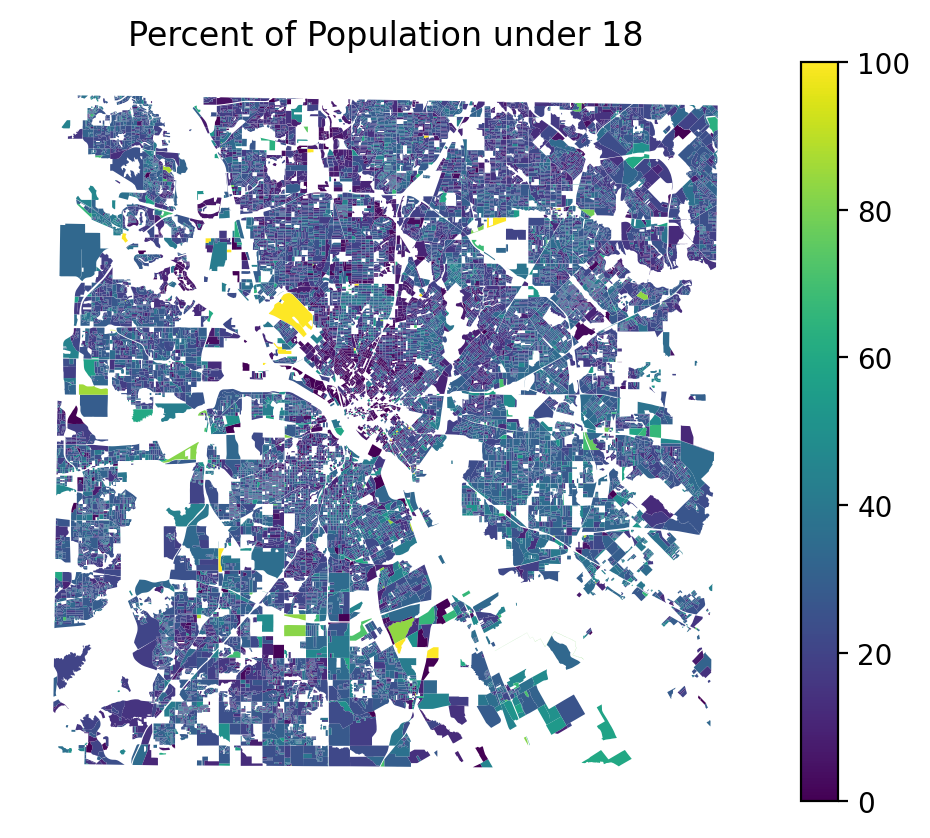

In [19]:
ax = geo_age.plot(column = "percent_child", legend = True)
#cx.add_basemap(ax)
ax.set_title("Percent of Population under 18")
ax.set_axis_off();

In [20]:
geo_age["percent_child"].sort_values(ascending = False)
geo_age.loc[29205]

GEO_ID                                             481130141592024
INTPTLAT20                                             +32.8958408
INTPTLON20                                            -096.9822000
HOUSING20                                                        1
POP20                                                            2
geometry         POLYGON ((-10796246.230526807 3881433.97960696...
Total                                                            2
Children                                                         2
Adults                                                           0
percent_child                                                100.0
Name: 29205, dtype: object

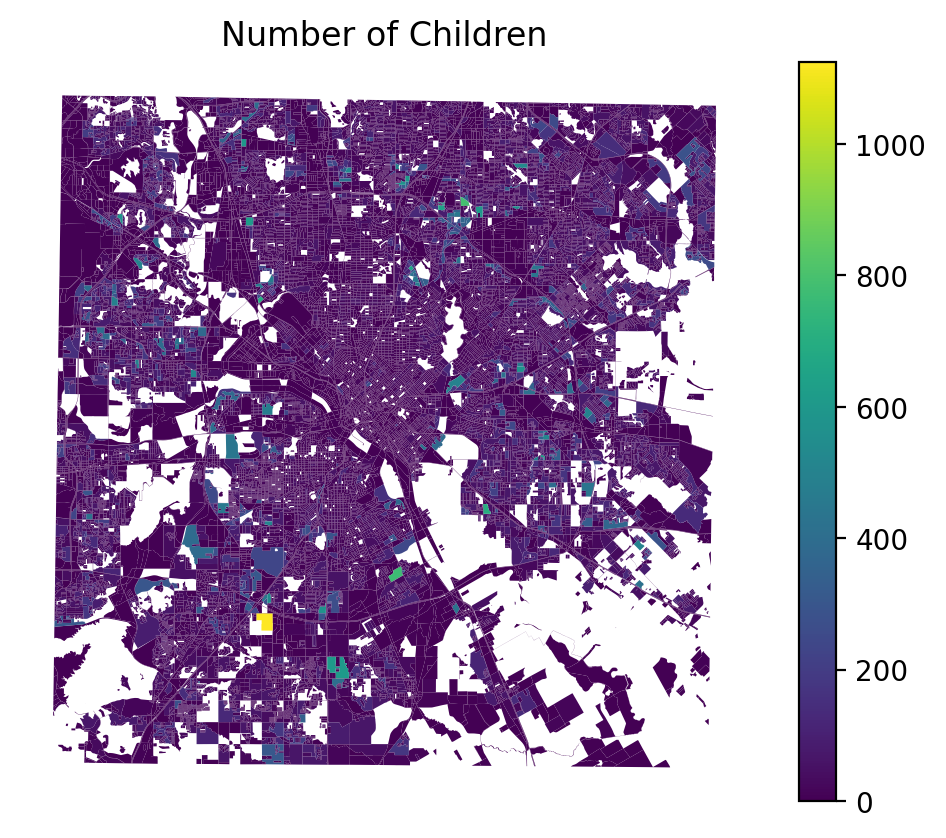

In [21]:
ax = geo_age.plot(column = "Children", legend = True)
#cx.add_basemap(ax)
ax.set_title("Number of Children")
ax.set_axis_off();

In [22]:
geo_age["Children"].sort_values(ascending = False)
geo_age.loc[6050]

GEO_ID                                             481130166352000
INTPTLAT20                                             +32.6422577
INTPTLON20                                            -096.8709365
HOUSING20                                                      715
POP20                                                         2329
geometry         POLYGON ((-10784459.722841615 3848107.75070007...
Total                                                         2329
Children                                                      1125
Adults                                                        1204
percent_child                                            48.303993
Name: 6050, dtype: object

In [23]:
test = geo_age.drop(labels = 6050, axis = 0)

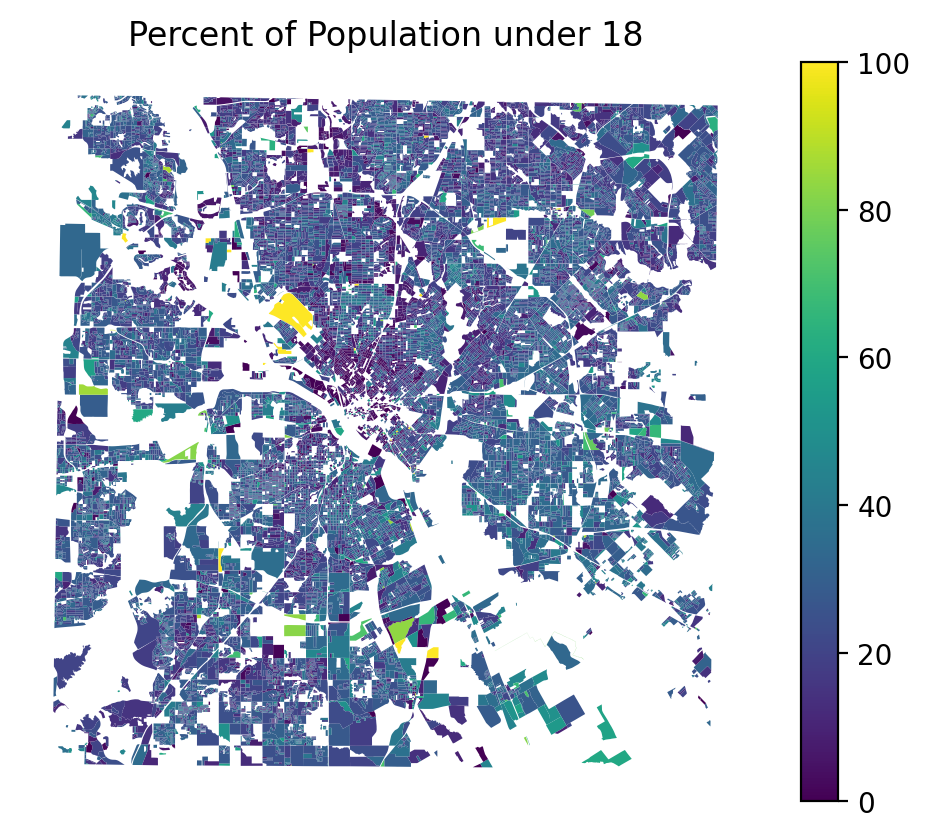

In [24]:
ax = test.plot(column = "percent_child", legend = True)
#cx.add_basemap(ax)
ax.set_title("Percent of Population under 18")
ax.set_axis_off();